# 02 · A tour of the bases

**Who this is for:** you know you need a modal basis but aren't sure which one. Each section below shows what the basis looks like, what it's good for, and the one or two parameters that matter. A decision table closes the notebook.

All bases are evaluated on the same DM: 20 actuators across a 10 m pupil.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import aobasis

plt.rcParams["figure.dpi"] = 80
positions = aobasis.make_circular_actuator_grid(telescope_diameter=10.0, grid_size=20)
n_act = len(positions)
print(n_act, "actuators")

276 actuators


## Karhunen-Loève (KL): the best basis for turbulence

KL modes are the eigenvectors of the covariance of atmospheric phase between actuators, under Von Kármán statistics. They're ordered by how much turbulent variance each one carries, and they're statistically independent. So for any `k`, the first `k` KL modes correct more turbulence than any other `k` modes. That makes them the default for AO control.

Parameters: `fried_parameter` (r0) and `outer_scale` (L0), in metres. r0 only scales the variances; L0 slightly changes the low-order modes.

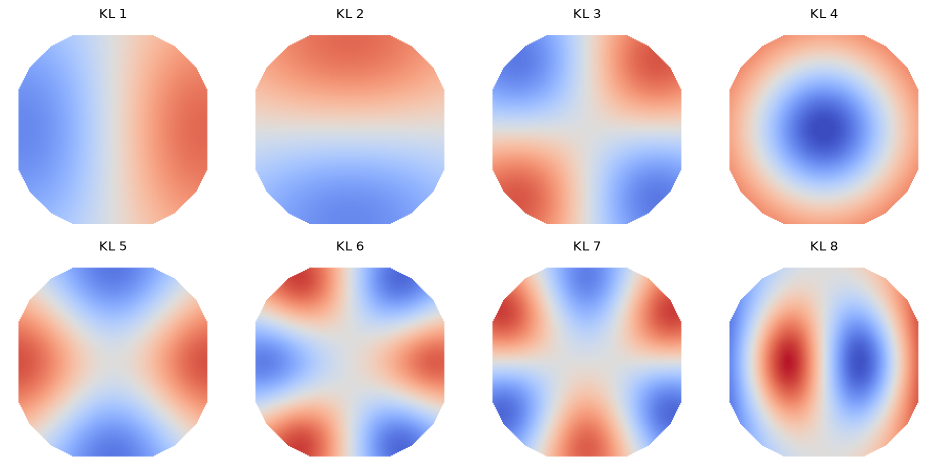

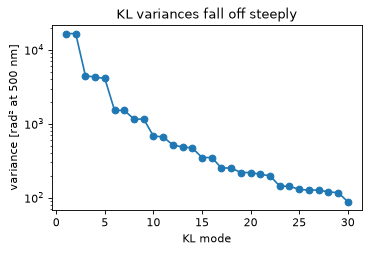

In [2]:
kl = aobasis.KLBasisGenerator(positions, fried_parameter=0.16, outer_scale=30.0)
kl.generate(30, ignore_piston=True)
kl.plot(count=8, title_prefix="KL", interpolate=True)

plt.figure(figsize=(5, 3))
plt.semilogy(np.arange(1, 31), kl.eigenvalues, "o-")
plt.xlabel("KL mode")
plt.ylabel("variance [rad² at 500 nm]")
plt.title("KL variances fall off steeply")
plt.show()

The low-order KL modes look like tip, tilt, defocus and astigmatism, but they're not Zernikes; their shapes follow the turbulence statistics. [05 · KL modes and turbulence](05_kl_and_turbulence.ipynb) goes deeper.

## Zernike polynomials: the language of optics

Zernikes are the classical aberrations: tip, tilt, defocus, astigmatism, coma, spherical, and so on. Use them when you need to *talk about* aberrations (optical testing, non-common-path calibration, a "put 50 nm of astigmatism on" command), or to compare with other optics software.

They're orthogonal over the continuous disk, **not** over a set of actuators, so sampled Zernikes are slightly correlated. `orthonormalize=True` fixes that; see [03](03_shaping_a_basis.ipynb). The parameter is `pupil_radius` (the radius of the unit disk), which defaults to the farthest actuator.

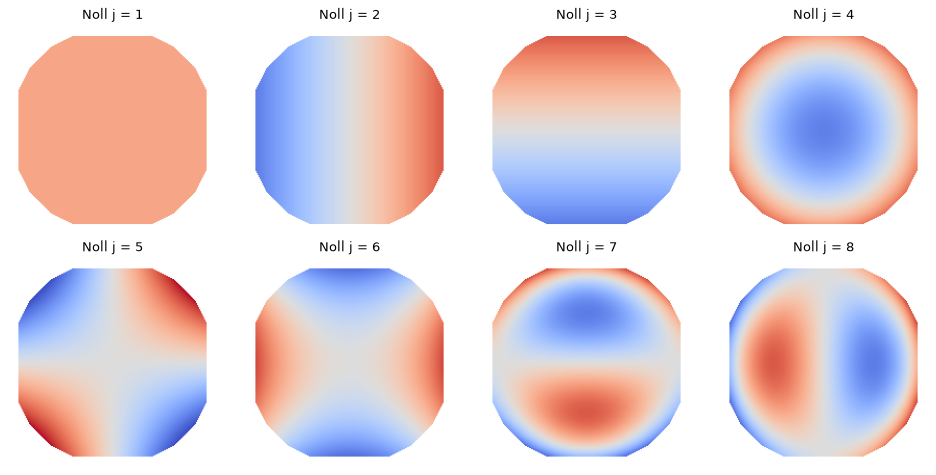

In [3]:
zern = aobasis.ZernikeBasisGenerator(positions, pupil_radius=5.0)
zern.generate(15)
zern.plot(count=8, title_prefix="Noll j =", interpolate=True)

The titles count from 1, so with the default Noll ordering title `j` is Noll index `j`: piston, tip, tilt, defocus, … OSA/ANSI and Fringe orderings are available through `generate(..., ordering="ansi")` or `"fringe"`.

## Fourier modes: spatial frequencies

Fourier modes are sines and cosines of increasing spatial frequency, in steps of one cycle per `pupil_diameter`. Use them to study the DM's frequency response, for spatial filtering, or for frequency-domain control ideas. Frequencies that alias on the actuator grid are skipped.

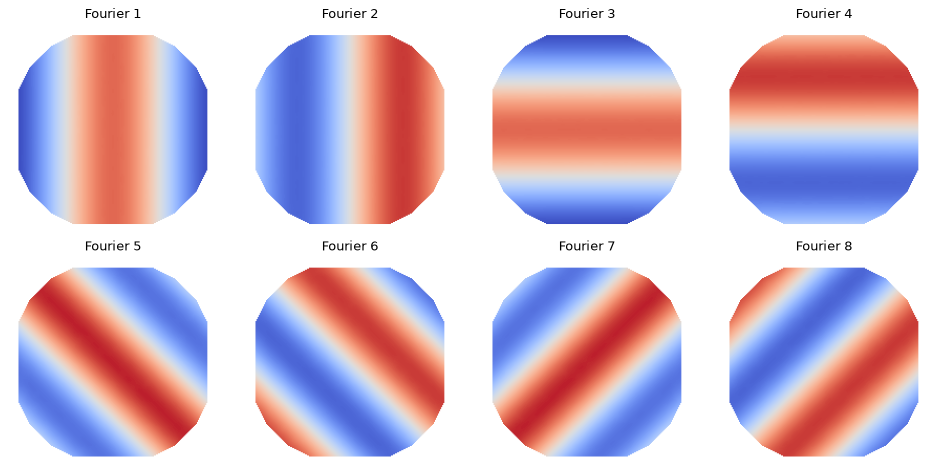

In [4]:
fourier = aobasis.FourierBasisGenerator(positions, pupil_diameter=10.0)
fourier.generate(15, ignore_piston=True)
fourier.plot(count=8, title_prefix="Fourier", interpolate=True)

## Zonal: one actuator at a time

The identity matrix: mode `k` pokes actuator `k`. It's the simplest calibration basis and the one people compare everything else with. Its drawback is cost: N actuators take N measurements, each with a single actuator's signal.

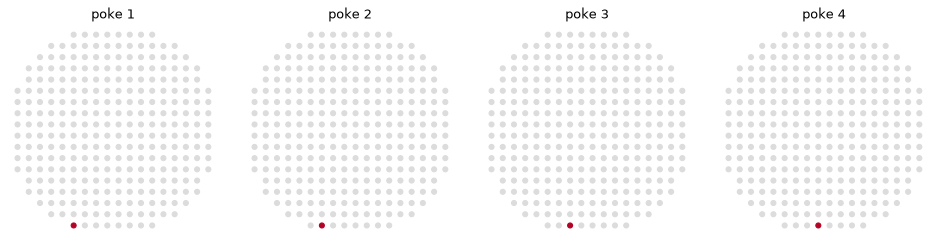

In [5]:
zonal = aobasis.ZonalBasisGenerator(positions)
zonal.generate(n_act)
zonal.plot(count=4, title_prefix="poke")

## Zonal fast: many well-separated pokes at once

If actuators far enough apart don't disturb each other's wavefront-sensor signal, you can poke them together and separate their responses afterwards. `ZonalFastBasisGenerator` groups the actuators into binary patterns so that no two actuators in a pattern are closer than `min_distance`. Every actuator appears in exactly one pattern.

12 patterns instead of 276 pokes


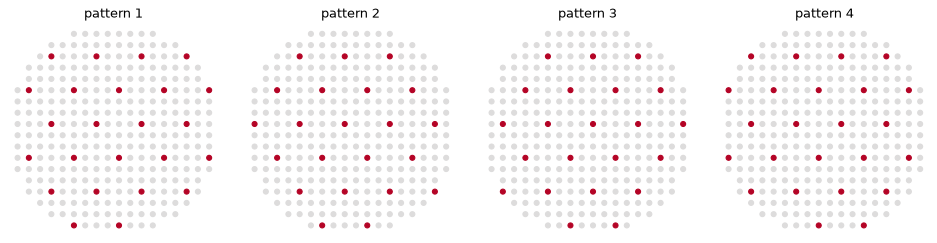

In [6]:
pitch = 10.0 / 19
fast = aobasis.ZonalFastBasisGenerator(positions, min_distance=3.5 * pitch)
patterns = fast.generate()
print(f"{patterns.shape[1]} patterns instead of {n_act} pokes")
fast.plot(count=4, title_prefix="pattern")

## Hadamard: every actuator in every measurement

Hadamard patterns are ±1 on every actuator, and the columns of a Hadamard matrix are orthogonal. Each measurement sees every actuator at full stroke. So for the same number of measurements, the calibration noise per actuator falls roughly as 1/√N compared with zonal pokes. That's the "multiplex advantage". [07 · Calibration](07_calibration.ipynb) measures it.

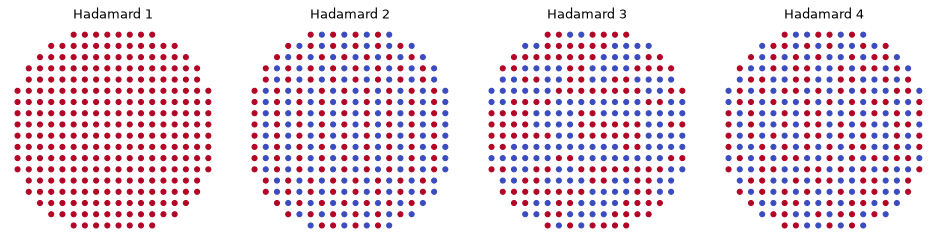

276 modes on 276 actuators, rank 276
condition number 1
largest |cos| between two modes 1.8e-17
piston content (|mean| / RMS): max 1
mode L2 norms 16.6 to 16.6


In [7]:
had = aobasis.HadamardBasisGenerator(positions)
had.generate(n_act, construction="smallest")
had.plot(count=4, title_prefix="Hadamard")
print(had.report())

`construction="smallest"` uses the smallest Hadamard matrix that fits. For this grid it's exactly 276×276, so the patterns are perfectly orthogonal. The `report()` above confirms it: condition number 1.

## Comparing them with numbers

`basis_report` summarizes any basis: rank, condition number (1 is perfect), the largest cosine between two modes (0 is orthogonal), and piston content.

In [8]:
bases = {
    "KL": kl.modes,
    "Zernike": aobasis.ZernikeBasisGenerator(positions, 5.0).generate(30, ignore_piston=True),
    "Fourier": aobasis.FourierBasisGenerator(positions, 10.0).generate(30, ignore_piston=True),
    "Hadamard": aobasis.HadamardBasisGenerator(positions).generate(30),
    "Zonal fast": patterns,
}
print(f"{'basis':<11}{'modes':>6}{'cond':>8}{'max cos':>9}{'max piston':>12}")
for name, modes in bases.items():
    r = aobasis.basis_report(modes)
    print(f"{name:<11}{r.n_modes:>6}{r.condition_number:>8.2f}{r.max_cosine:>9.3f}{r.piston_content.max():>12.3f}")

basis       modes    cond  max cos  max piston
KL             30    1.00    0.000       0.000
Zernike        30    1.95    0.269       0.000
Fourier        30    7.84    0.310       0.000
Hadamard       30    1.06    0.043       1.000
Zonal fast     12    1.04    0.000       0.295


A few things to notice:

- **KL** is perfectly orthonormal and piston-free.
- **Zernike and Fourier** are orthogonal only as continuous functions. Sampled at 276 points, some pairs correlate by about 0.3; pass `orthonormalize=True` if that matters (notebook 03).
- **Hadamard** includes piston as its first column, unless you pass `ignore_piston=True`.
- **Zonal fast** patterns are orthogonal (no shared actuators) but not normalized.

## Which basis should I use?

| Task | Basis | Why |
|---|---|---|
| Closed-loop AO control of turbulence | **KL** (or `DMKLBasisGenerator` with real influence functions) | most variance in fewest modes; independent coefficients |
| Aberration commands, optical testing, NCPA | **Zernike** | standard, interpretable |
| Frequency response, spatial filtering | **Fourier** | one spatial frequency per mode |
| Interaction-matrix calibration, low noise | **Hadamard** | multiplex advantage, ±1 full stroke |
| Interaction-matrix calibration, few measurements | **Zonal fast** | measurement count independent of N |
| Simplest calibration, debugging | **Zonal** | one actuator per measurement |

A common pattern: *calibrate* with Hadamard or zonal-fast patterns to get the zonal interaction matrix, then *control* with KL modes (modal interaction matrix = zonal IM @ M2C). Notebook 07 does exactly that.